### Задача

Датасет embedded_system_network_security_dataset описывает логи сетевой безопасности, необходимо научиться определять аномалии используя AE VAE и проиллюстрировать результаты.

In [56]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import Adam
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os
import warnings

In [57]:
warnings.filterwarnings('ignore')

In [58]:
BATCH_SIZE = 16
EPOCHS = 150
LEARNING_RATE = 0.0034
LATENT_DIM = 4
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

Чтобы все шустренько работало, будем обучаться на gpu

In [59]:
DEVICE

device(type='cuda', index=0)

Поделим выборку на train, val, test

In [60]:
df = pd.read_csv('embedded_system_network_security_dataset.csv')
data = df.drop(columns=['src_port', 'mean_packet_size'])

port_mapping = {443: [1,0,0], 80: [0,1,0], 53: [0,0,1]}
port_encoded = data['dst_port'].map(port_mapping)
port_df = pd.DataFrame(port_encoded.tolist(), columns=['port_443','port_80','port_53'], index=data.index)
data = pd.concat([data.drop(columns=['dst_port']), port_df], axis=1)

y = data['label'].values
X = data.drop(columns=['label']).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

normal_mask = (y == 0)
normal_indices = np.where(normal_mask)[0]
anomaly_indices = np.where(y == 1)[0]

val_ratio = 0.2
val_normal_count = max(1, int(len(normal_indices) * val_ratio))
val_anomaly_count = max(1, int(len(anomaly_indices) * val_ratio))

val_normal_idx = np.random.choice(normal_indices, val_normal_count, replace=False)
val_anomaly_idx = np.random.choice(anomaly_indices, val_anomaly_count, replace=False)
val_indices = np.concatenate([val_normal_idx, val_anomaly_idx])

train_indices = np.setdiff1d(normal_indices, val_normal_idx)

X_train = X_scaled[train_indices]
X_val = X_scaled[val_indices]
y_val = y[val_indices]
X_test = X_scaled
y_test = y

print(f"Train (только нормальные): {X_train.shape[0]}")
print(f"Val: {X_val.shape[0]} (нормальные: {(y_val==0).sum()}, аномалии: {(y_val==1).sum()})")
print(f"Test: {X_test.shape[0]} (нормальные: {(y_test==0).sum()}, аномалии: {(y_test==1).sum()})")

input_size = X_train.shape[1]


Train (только нормальные): 720
Val: 200 (нормальные: 180, аномалии: 20)
Test: 1000 (нормальные: 900, аномалии: 100)


In [61]:
train_dataset = TensorDataset(torch.tensor(X_train.astype(np.float32)))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = TensorDataset(torch.tensor(X_val.astype(np.float32)), torch.tensor(y_val.astype(np.long)))
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = TensorDataset(torch.tensor(X_test.astype(np.float32)), torch.tensor(y_test.astype(np.long)))
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


### Реализуем Автоэнкодер.

In [62]:
class Autoencoder(nn.Module):
    def __init__(self, input_size):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 16),
            nn.LeakyReLU(0.2),
            nn.Linear(16, 4),
            nn.LeakyReLU(0.2),
        )
        self.decoder = nn.Sequential(
            nn.Linear(4, 16),
            nn.LeakyReLU(0.2),
            nn.Linear(16, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, input_size),
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

ae_model = Autoencoder(input_size).to(DEVICE)
ae_criterion = nn.MSELoss()
per_sample_criterion = nn.MSELoss(reduction="none")
ae_optimizer = Adam(ae_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)


Обучим его на 150 эпохах. 

In [63]:
ae_losses = []
for epoch in range(EPOCHS):
    running_loss = 0.0
    for (x_batch,) in train_loader:
        x_batch = x_batch.to(DEVICE)
        output = ae_model(x_batch)
        loss = ae_criterion(output, x_batch)
        
        ae_optimizer.zero_grad()
        loss.backward()
        ae_optimizer.step()
        running_loss += loss.item()
    
    avg_loss = running_loss / len(train_loader)
    ae_losses.append(avg_loss)
    if (epoch+1) % 20 == 0:
        print(f"AE Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.6f}")

AE Epoch [20/150], Loss: 0.380182
AE Epoch [40/150], Loss: 0.289652
AE Epoch [60/150], Loss: 0.237609
AE Epoch [80/150], Loss: 0.201676
AE Epoch [100/150], Loss: 0.187900
AE Epoch [120/150], Loss: 0.178103
AE Epoch [140/150], Loss: 0.162640


Протестируем AE

In [64]:
def evaluate_model(model, val_loader, test_loader, device, model_name):
    model.eval()
    val_errors, val_labels = [], []
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            output = model(x_batch)
            loss = torch.mean((output - x_batch)**2, dim=1)
            val_errors.append(loss.cpu().numpy())
            val_labels.append(y_batch.numpy())
    
    val_errors = np.concatenate(val_errors)
    val_labels = np.concatenate(val_labels)
    
    test_errors, test_labels = [], []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            output = model(x_batch)
            loss = torch.mean((output - x_batch)**2, dim=1)
            test_errors.append(loss.cpu().numpy())
            test_labels.append(y_batch.numpy())
    
    test_errors = np.concatenate(test_errors)
    test_labels = np.concatenate(test_labels)
    
    threshold = np.percentile(val_errors[val_labels==0], 85)
    y_pred = (test_errors > threshold).astype(int)
    
    print(f"\n{model_name} - Результаты:")
    print(classification_report(test_labels, y_pred, target_names=['Normal','Anomaly']))
    print(f"ROC-AUC: {roc_auc_score(test_labels, test_errors):.4f}")
    print(f"Threshold: {threshold:.4f}")
    
    return test_errors, test_labels, y_pred

In [65]:
ae_errors, ae_labels, ae_pred = evaluate_model(ae_model, val_loader, test_loader, DEVICE, "Autoencoder")


Autoencoder - Результаты:
              precision    recall  f1-score   support

      Normal       0.92      0.97      0.94       900
     Anomaly       0.45      0.22      0.30       100

    accuracy                           0.90      1000
   macro avg       0.68      0.59      0.62      1000
weighted avg       0.87      0.90      0.88      1000

ROC-AUC: 0.7513
Threshold: 0.5884


Видим, что precision на аномалиях у нас примерно 0.5, значит точность какая никакая у нас присутствует (50% среди предсказанных аномалией действительно ей являются), учитывая число аномалий в валидационной выборке это неплохо. Но например f1-score и recall показывают какой ценой это достигается - полнота распознавания аномалий на самом деле очень низкая, значит мы определяем лишь 22% аномалий среди всех.

In [66]:
class VariationalEncoder(nn.Module):
    def __init__(self, input_dim, latent_dims):
        super(VariationalEncoder, self).__init__()
        self.linear1 = nn.Linear(input_dim, 512)
        self.linear2 = nn.Linear(512, latent_dims)
        self.linear3 = nn.Linear(512, latent_dims)
        self.N = torch.distributions.Normal(0, 1)
        self.kl = 0

    def forward(self, x):
        x = torch.flatten(x, start_dim=1) if len(x.shape) > 2 else x
        x = torch.relu(self.linear1(x))
        mu = self.linear2(x)
        sigma = torch.exp(self.linear3(x))
        z = mu + sigma * self.N.sample(mu.shape).to(mu.device)
        self.kl = (sigma**2 + mu**2 - torch.log(sigma) - 1/2).sum()
        return z

class Decoder(nn.Module):
    def __init__(self, latent_dims, output_dim):
        super(Decoder, self).__init__()
        self.linear1 = nn.Linear(latent_dims, 512)
        self.linear2 = nn.Linear(512, output_dim)

    def forward(self, z):
        z = torch.relu(self.linear1(z))
        return self.linear2(z)

class VariationalAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dims):
        super(VariationalAutoencoder, self).__init__()
        self.encoder = VariationalEncoder(input_dim, latent_dims)
        self.decoder = Decoder(latent_dims, input_dim)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

vae_model = VariationalAutoencoder(input_size, LATENT_DIM).to(DEVICE)
vae_optimizer = Adam(vae_model.parameters(), lr=LEARNING_RATE)

Здесь я предположил, что было бы разумно понизить вклад ошибки от kl дивергенции, делать больший акцент на реконструкции , но при этом оставляя стремление латентного пространства соблюдать нормальную структуру. Я подумал, что в таком случае, попавшие в кодировщик аномалии мало того, что будут плохо декодированы, так еще и не будут вписываться в распределение латентного пространства. 

Обучая на 350 эпохах, хотябы потому, что архитектура более тяжелая, чем у представленного выше AE.

In [67]:
vae_losses = []
EPOCHS = 350
for epoch in range(EPOCHS):
    running_loss = 0.0
    for (x_batch,) in train_loader:
        x_batch = x_batch.to(DEVICE)
        x_hat = vae_model(x_batch)
        recon_loss = ((x_batch - x_hat)**2).sum()
        loss = recon_loss + vae_model.encoder.kl * 0.0001
        vae_optimizer.zero_grad()
        loss.backward()
        vae_optimizer.step()
        running_loss += loss.item()
    
    avg_loss = running_loss / len(train_loader)
    vae_losses.append(avg_loss)
    if (epoch+1) % 20 == 0:
        print(f"VAE Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.6f}")

VAE Epoch [20/350], Loss: 88.008314
VAE Epoch [40/350], Loss: 71.089045
VAE Epoch [60/350], Loss: 60.117507
VAE Epoch [80/350], Loss: 54.077168
VAE Epoch [100/350], Loss: 52.556709
VAE Epoch [120/350], Loss: 45.880802
VAE Epoch [140/350], Loss: 41.630812
VAE Epoch [160/350], Loss: 41.307890
VAE Epoch [180/350], Loss: 38.792484
VAE Epoch [200/350], Loss: 36.752153
VAE Epoch [220/350], Loss: 36.037916
VAE Epoch [240/350], Loss: 33.687275
VAE Epoch [260/350], Loss: 31.673896
VAE Epoch [280/350], Loss: 29.879155
VAE Epoch [300/350], Loss: 28.787142
VAE Epoch [320/350], Loss: 28.140138
VAE Epoch [340/350], Loss: 25.272710


In [68]:
def evaluate_vae(model, val_loader, test_loader, device, model_name):
    model.eval()
    val_errors, val_labels = [], []
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            x_hat = model(x_batch)
            loss = torch.mean((x_hat - x_batch)**2, dim=1)
            val_errors.append(loss.cpu().numpy())
            val_labels.append(y_batch.numpy())
    
    val_errors = np.concatenate(val_errors)
    val_labels = np.concatenate(val_labels)
    
    test_errors, test_labels = [], []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            x_hat = model(x_batch)
            loss = torch.mean((x_hat - x_batch)**2, dim=1)
            test_errors.append(loss.cpu().numpy())
            test_labels.append(y_batch.numpy())
    
    test_errors = np.concatenate(test_errors)
    test_labels = np.concatenate(test_labels)
    
    threshold = np.percentile(val_errors[val_labels==0], 85)
    y_pred = (test_errors > threshold).astype(int)
    
    print(f"\n{model_name} - Результаты:")
    print(classification_report(test_labels, y_pred, target_names=['Normal','Anomaly']))
    print(f"ROC-AUC: {roc_auc_score(test_labels, test_errors):.4f}")
    print(f"Threshold: {threshold:.4f}")
    
    return test_errors, test_labels, y_pred

vae_errors, vae_labels, vae_pred = evaluate_vae(vae_model, val_loader, test_loader, DEVICE, "Variational Autoencoder")


Variational Autoencoder - Результаты:
              precision    recall  f1-score   support

      Normal       0.91      0.97      0.94       900
     Anomaly       0.36      0.16      0.22       100

    accuracy                           0.89      1000
   macro avg       0.64      0.56      0.58      1000
weighted avg       0.86      0.89      0.87      1000

ROC-AUC: 0.8406
Threshold: 0.5992


Видим рост roc-auc по сравнению с AE, но было бы интересно посмотреть не на него, а все-таки на PR-кривую, чтобы получить понимание насколько вообще хорошо мы работаем именно с аномалиями.

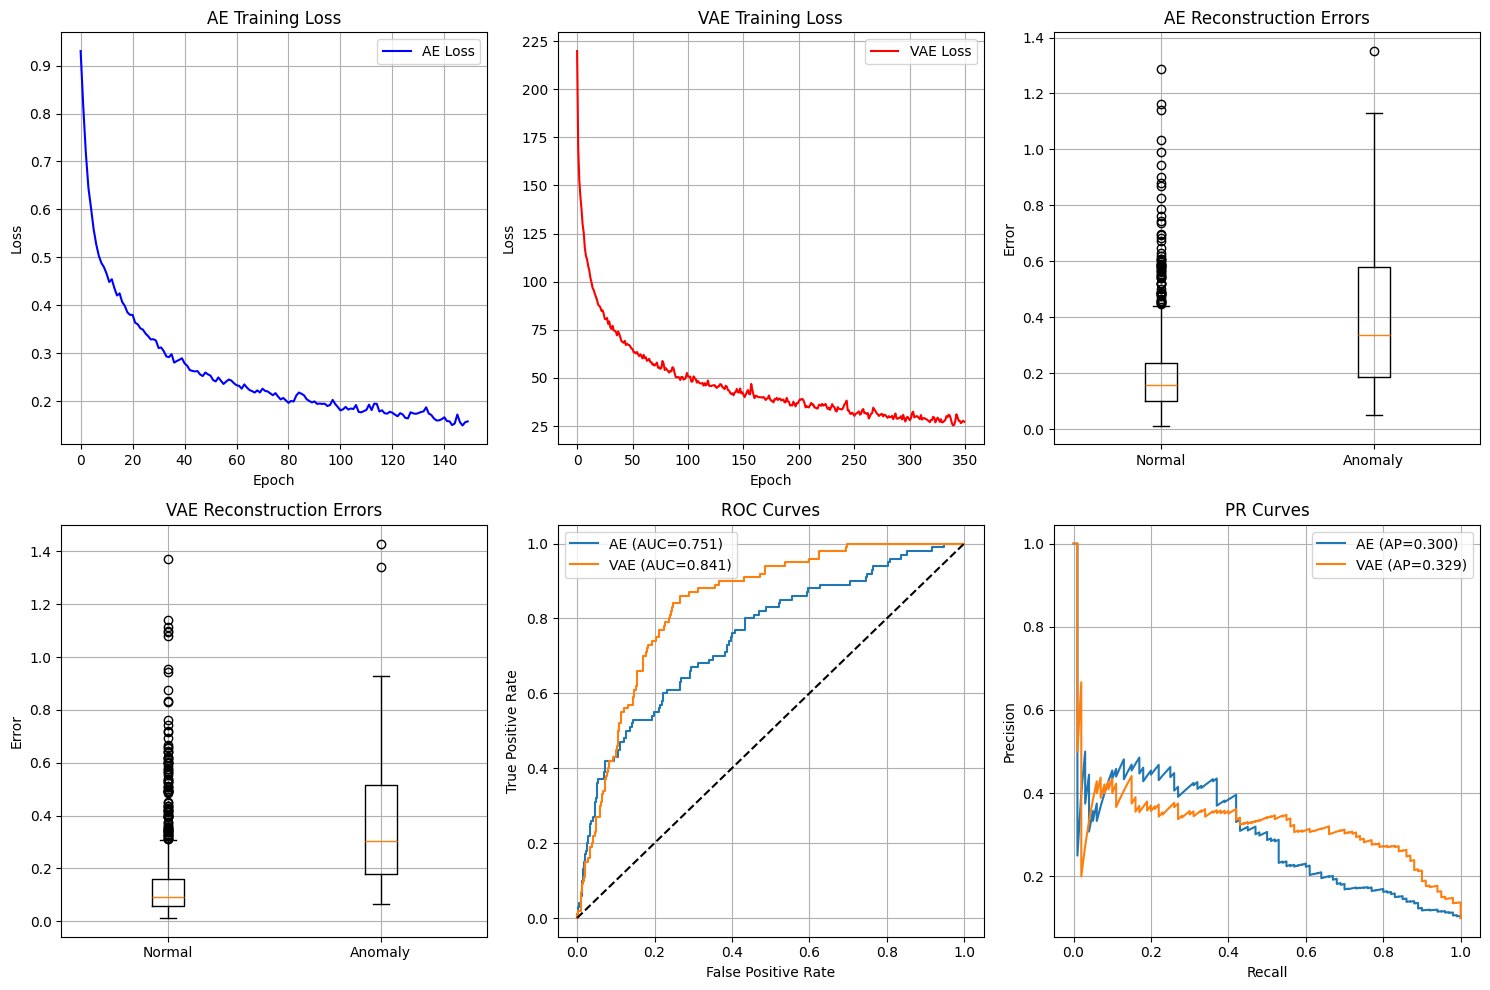

In [69]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.plot(ae_losses, label='AE Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('AE Training Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 2)
plt.plot(vae_losses, label='VAE Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VAE Training Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 3)
plt.boxplot([ae_errors[ae_labels==0], ae_errors[ae_labels==1]], labels=['Normal', 'Anomaly'])
plt.title('AE Reconstruction Errors')
plt.ylabel('Error')
plt.grid(True)

plt.subplot(2, 3, 4)
plt.boxplot([vae_errors[vae_labels==0], vae_errors[vae_labels==1]], labels=['Normal', 'Anomaly'])
plt.title('VAE Reconstruction Errors')
plt.ylabel('Error')
plt.grid(True)

plt.subplot(2, 3, 5)
for name, errors in [('AE', ae_errors), ('VAE', vae_errors)]:
    fpr, tpr, _ = roc_curve(ae_labels, errors)
    auc_score = roc_auc_score(ae_labels, errors)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 6)
for name, errors in [('AE', ae_errors), ('VAE', vae_errors)]:
    precision, recall, _ = precision_recall_curve(ae_labels, errors)
    ap_score = average_precision_score(ae_labels, errors)
    plt.plot(recall, precision, label=f'{name} (AP={ap_score:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR Curves')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Как я и предполагал метрики у VAE повыше. Это все благодаря KL дивергенции конечно. AP у VAE как и ожидалось - выше, но не настолько, чтобы говорить о каких-то значимых достижениях.

Также для наглядности показываю аспределение уже раскрашенных данных с порогом, по которому модели определяют "аномальность" (85%)

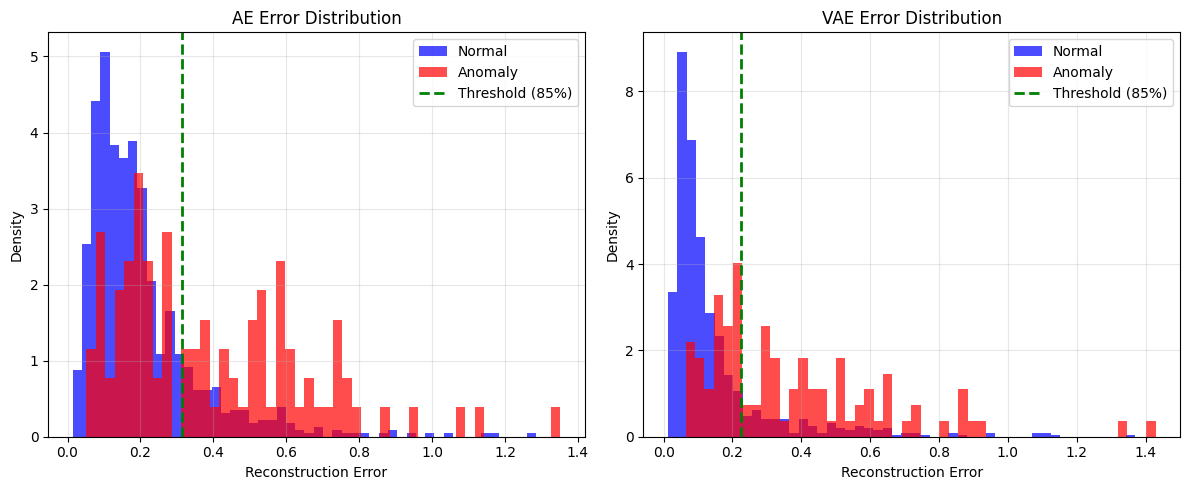

In [70]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(ae_errors[ae_labels==0], bins=50, alpha=0.7, color='blue', label='Normal', density=True)
plt.hist(ae_errors[ae_labels==1], bins=50, alpha=0.7, color='red', label='Anomaly', density=True)
plt.axvline(x=np.percentile(ae_errors[ae_labels==0], 85), color='green', linestyle='--', 
           linewidth=2, label='Threshold (85%)')
plt.xlabel('Reconstruction Error')
plt.ylabel('Density')
plt.title('AE Error Distribution')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(vae_errors[vae_labels==0], bins=50, alpha=0.7, color='blue', label='Normal', density=True)
plt.hist(vae_errors[vae_labels==1], bins=50, alpha=0.7, color='red', label='Anomaly', density=True)
plt.axvline(x=np.percentile(vae_errors[vae_labels==0], 85), color='green', linestyle='--', 
           linewidth=2, label='Threshold (85%)')
plt.xlabel('Reconstruction Error')
plt.ylabel('Density')
plt.title('VAE Error Distribution')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()